In [1]:
# Install dependency dengan versi terpin (Python 3.11+)
%pip install -q pandas==3.0.6 numpy==2.3.2 matplotlib==3.10.8 requests==2.32.5 pyarrow==21.0.0 lightgbm==4.6.0


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pandas==3.0.6 (from versions: none)
ERROR: No matching distribution found for pandas==3.0.6


In [2]:
# import library
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

## 1. Data acquisition dan loading

Dataset kompetisi tersedia di `dataset/`. Metadata publik untuk 20 judul yang tidak tercantum pada katalog lokal tersimpan di `external_data/missing_movies_metadata.csv`; sumber, endpoint, tanggal pengambilan, atribusi, dan audit kecocokan judul dicatat di `external_data/`. Akuisisi ulang dapat dilakukan melalui `scripts/build_pipeline.py --fetch-metadata` dengan variabel TMDB di `.env`.

In [3]:

DATASET_DIR = Path("dataset")
SUPPORTED_EXTENSIONS = {".csv"}

datasets = {}

for file_path in sorted(DATASET_DIR.iterdir()):
    if not file_path.is_file() or file_path.suffix.lower() not in SUPPORTED_EXTENSIONS:
        continue

    try:
        extension = file_path.suffix.lower()
        if extension == ".csv":
            data = pd.read_csv(file_path)
        elif extension in {".xlsx", ".xls"}:
            data = pd.read_excel(file_path)
        elif extension == ".json":
            data = pd.read_json(file_path)
        else:
            data = pd.read_parquet(file_path)

        datasets[file_path.stem] = data
        print(f"\n{'=' * 80}\nDataset: {file_path.name}")
        print(f"Ukuran: {data.shape[0]:,} baris x {data.shape[1]:,} kolom")
        print("\nTipe data:")
        print(data.dtypes)
        print("\nMissing values:")
        missing = data.isna().sum().sort_values(ascending=False)
        print(missing[missing > 0] if missing.any() else "Tidak ada missing values")
        print("\nDuplikat:")
        print(data.duplicated().sum())
        print("\nStatistik numerik:")
        display(data.describe().T)
        print("\nLima baris pertama:")
        display(data.head())
    except Exception as error:
        print(f"Gagal memuat {file_path.name}: {error}")

print(f"\nTotal dataset berhasil dimuat: {len(datasets)}")
print("Nama dataset:", list(datasets.keys()))


Dataset: holidays.csv
Ukuran: 366 baris x 4 kolom

Tipe data:
date            object
day_tipe        object
holiday_tipe    object
holiday_name    object
dtype: object

Missing values:
holiday_name    348
dtype: int64

Duplikat:
0

Statistik numerik:


,count,unique,top,freq
date,366,366,2025-04-01,1
day_tipe,366,3,weekday,210
holiday_tipe,366,2,normal,348
holiday_name,18,17,Idulfitri 1447 H,2



Lima baris pertama:


,date,day_tipe,holiday_tipe,holiday_name
0,2025-04-01,weekday,holiday,Idulfitri 1446 H
1,2025-04-02,weekday,normal,NaN
2,2025-04-03,weekday,normal,NaN
3,2025-04-04,friday,normal,NaN
4,2025-04-05,weekend,normal,NaN



Dataset: movies.csv
Ukuran: 397 baris x 7 kolom

Tipe data:
original_title    object
age_rating        object
genre             object
producer          object
director          object
writer            object
casts             object
dtype: object

Missing values:
age_rating    3
dtype: int64

Duplikat:
0

Statistik numerik:


...


Dataset: train.csv
Ukuran: 138,959 baris x 7 kolom

Tipe data:
date_show           object
cinema_ids          object
city_name           object
movie_title         object
total_ticket         int64
occupation_rate    float64
total_show           int64
dtype: object

Missing values:
Tidak ada missing values

Duplikat:
0

Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
total_ticket,138959.0,354.122072,725.927987,1.0,69.00,161.00,361.00,32845.0
occupation_rate,138959.0,28.331061,22.618841,0.0,12.36,21.84,37.01,100.0
total_show,138959.0,7.730921,11.005488,1.0,3.00,5.00,8.00,285.0



Lima baris pertama:


,date_show,cinema_ids,city_name,movie_title,total_ticket,occupation_rate,total_show
0,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,A WORKING MAN,487,31.07,18
1,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,JUMBO,649,23.69,19
2,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,KOMANG,389,9.55,22
3,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,NE ZHA 2,101,70.03,3
4,2025-04-01,015555fbcd8faef6b55a854605df0a87,SURABAYA,NORMA: ANTARA MERTUA DAN MENANTU,411,17.76,13



Total dataset berhasil dimuat: 7
Nama dataset: ['holidays', 'movies', 'sample_submission', 'test', 'test_history', 'ticket_prices', 'train']


## 2. Preprocessing dan pemeriksaan kualitas

Cell berikut memeriksa konsistensi kunci, tanggal, dan kelengkapan antar-sumber sebelum analisis.

data yg missing sangat sedikit, termasuk lengkap.

## 3. Exploratory data analysis

Analisis berikut meninjau skala target, kalender/libur, karakter cluster, harga, genre, serta anomali historis.

In [4]:
# Validasi key dan kelengkapan data antar dataset
train = datasets["train"].copy()
test_history = datasets["test_history"].copy()
test = datasets["test"].copy()
movies = datasets["movies"].copy()
ticket_prices = datasets["ticket_prices"].copy()
holidays = datasets["holidays"].copy()

for data, date_column in [
    (train, "date_show"),
    (test_history, "date_show"),
    (test, "date_show"),
    (holidays, "date"),
]:
    data[date_column] = pd.to_datetime(data[date_column])

# 1. Cinema cluster: histori vs periode test
history_cinema_ids = set(train["cinema_ids"]) | set(test_history["cinema_ids"])
test_cinema_ids = set(test["cinema_ids"])
print("Cinema IDs hanya muncul di histori:", len(history_cinema_ids - test_cinema_ids))
print("Cinema IDs hanya muncul di test:", len(test_cinema_ids - history_cinema_ids))
print("Cinema IDs muncul di keduanya:", len(history_cinema_ids & test_cinema_ids))

# 2. Movie title: exact match dan kandidat setelah normalisasi sederhana
normalize_title = lambda series: (
    series.astype("string")
    .str.upper()
    .str.replace(r"\\(\\s*(2D|3D|IMAX|DUBBING)\\s*\\)", "", regex=True)
    .str.replace(r"\\b(2D|3D|IMAX|DUBBING)\\b", "", regex=True)
    .str.replace(r"[^A-Z0-9]+", " ", regex=True)
    .str.replace(r"\\s+", " ", regex=True)
    .str.strip()
)

movie_titles = set(movies["original_title"].dropna())
test_titles = set(test["movie_title"].dropna())
missing_exact_titles = sorted(test_titles - movie_titles)
print("\\nMovie title test yang tidak exact-match ke movies.csv:", len(missing_exact_titles))
print(missing_exact_titles[:20])

normalized_movie_titles = set(normalize_title(movies["original_title"].dropna()))
normalized_test_titles = normalize_title(pd.Series(missing_exact_titles))
resolved_after_normalization = set(normalized_test_titles) & normalized_movie_titles
print("Kandidat yang match setelah normalisasi format/spasi:", len(resolved_after_normalization))
print("Masih tidak ditemukan setelah normalisasi:", len(set(normalized_test_titles) - normalized_movie_titles))

# 3. Konsistensi nama kota
city_sources = {
    "train": train["city_name"],
    "test": test["city_name"],
    "ticket_prices": ticket_prices["city_name"],
}
normalized_city_sets = {
    name: set(values.dropna().astype("string").str.upper().str.strip())
    for name, values in city_sources.items()
}
all_cities = set.union(*normalized_city_sets.values())
city_comparison = pd.DataFrame({
    name: sorted(all_cities).copy() for name in normalized_city_sets
})
print("\\nJumlah kota unik:")
print({name: len(values) for name, values in normalized_city_sets.items()})
print("Kota yang ada di train tetapi tidak di ticket_prices:", sorted(normalized_city_sets["train"] - normalized_city_sets["ticket_prices"]))
print("Kota yang ada di test tetapi tidak di ticket_prices:", sorted(normalized_city_sets["test"] - normalized_city_sets["ticket_prices"]))

# 4. Setiap pasangan film-klaster di test harus memiliki 7 hari
pair_counts = test.groupby(["movie_title", "cinema_ids"]).size()
print("\\nDistribusi jumlah baris per pasangan film-klaster:")
print(pair_counts.value_counts().sort_index())
invalid_pairs = pair_counts[pair_counts != 7]
print(f"Pasangan yang bukan 7 baris: {len(invalid_pairs)}")
display(invalid_pairs.head(20).rename("jumlah_baris").to_frame())

Cinema IDs hanya muncul di histori: 0
Cinema IDs hanya muncul di test: 0
Cinema IDs muncul di keduanya: 121
\nMovie title test yang tidak exact-match ke movies.csv: 20
['AVATAR: FIRE AND ASH (3D)', 'AVATAR: FIRE AND ASH (IMAX 3D)', 'BLADES OF THE GUARDIANS (IMAX 2D)', 'DANUR: THE LAST CHAPTER (IMAX 2D)', 'EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)', 'HOPPERS (3D)', 'HOPPERS (IMAX 2D)', 'MERCY (IMAX 2D)', 'PREDATOR: BADLANDS (3D)', 'PREDATOR: BADLANDS (IMAX 2D)', 'SCREAM 7 (IMAX 2D)', 'STRAY KIDS: THE DOMINATE EXPERIENCE (IMAX 2D)', 'THE BRIDE! (IMAX 2D)', 'THE RUNNING MAN (IMAX 2D)', 'TRON: ARES (3D)', 'TRON: ARES (IMAX 2D)', 'WICKED: FOR GOOD (3D)', 'WICKED: FOR GOOD (IMAX 2D)', 'WUTHERING HEIGHTS (IMAX 2D)', 'ZOOTOPIA 2 (IMAX 2D)']
Kandidat yang match setelah normalisasi format/spasi: 0
Masih tidak ditemukan setelah normalisasi: 20


\nJumlah kota unik:
{'train': 67, 'test': 69, 'ticket_prices': 69}
Kota yang ada di train tetapi tidak di ticket_prices: []
Kota yang ada di test tetapi tidak di ticket_prices: []
\nDistribusi jumlah baris per pasangan film-klaster:
7    10373
Name: count, dtype: int64
Pasangan yang bukan 7 baris: 0


,,jumlah_baris
movie_title,cinema_ids,


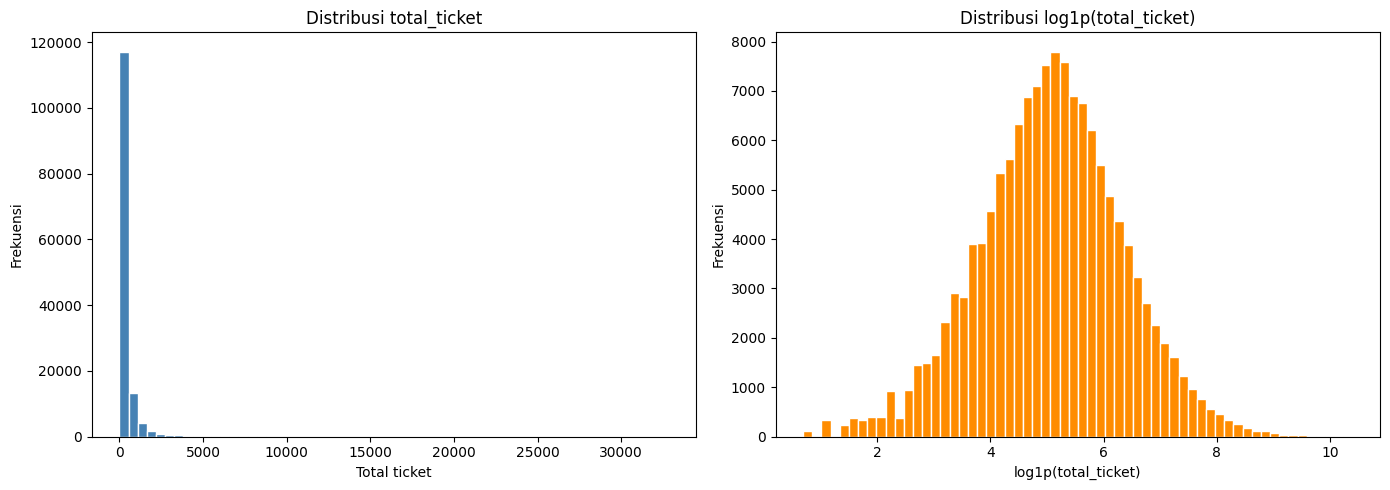

Ringkasan scale_raw:


,scale_raw
count,11823.000000
mean,208.907722
std,553.826492
min,1.000000
25%,28.000000
50%,78.000000
75%,202.000000
max,24117.333333


Pasangan yang benar-benar di-clip oleh max(1, scale): 0 (0.00%)
Pasangan yang berada di floor scale=1: 23 (0.19%)
Lima pasangan dengan scale terkecil:


,movie_title,cinema_ids,scale_raw,max_ticket,min_ticket,mean_total_show,mean_occupation_rate,n_obs,scale,was_clipped,at_floor
1288,BLACK PHONE 2,4a61d7e09bbe3868d79af81be96ed6ee,1.0,1,1,2.5,0.87,2,1.0,False,True
1515,CAUGHT STEALING,df7f047e9886cfa1c0892c97f15d4146,1.0,1,1,2.0,1.03,1,1.0,False,True
2329,EPIC: ELVIS PRESLEY IN CONCERT,f3a9ac312f7bc4e2467a1bf02a6aa1e9,1.0,1,1,5.0,0.00,1,1.0,False,True
2567,G-DRAGON IN CINEMA: UBERMENSCH,da96492ebd43c4a193238d6c3205cc40,1.0,1,1,1.0,0.00,2,1.0,False,True
2572,G-DRAGON IN CINEMA: UBERMENSCH,ea7df0c99b450ecdea38cf34ae1f158f,1.0,1,1,1.0,0.00,1,1.0,False,True


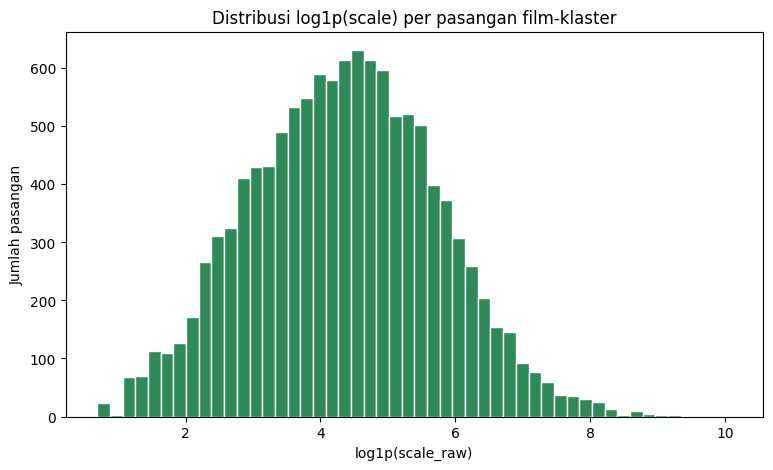

In [5]:
# Distribusi total_ticket dan skala MASE dari tiga hari histori pertama
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train["total_ticket"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Distribusi total_ticket")
axes[0].set_xlabel("Total ticket")
axes[0].set_ylabel("Frekuensi")
axes[1].hist(np.log1p(train["total_ticket"]), bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("Distribusi log1p(total_ticket)")
axes[1].set_xlabel("log1p(total_ticket)")
axes[1].set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()


def compute_history_stats(history_df, n_days=3, id_cols=("movie_title", "cinema_ids")):
    """Hitung statistik agregat dari n hari PERTAMA observasi per pasangan
    (default: D1-D3, sesuai definisi hitung_skala pada deskripsi kompetisi).

    Diambil dengan cara: urutkan ascending berdasarkan date_show, lalu ambil
    n baris pertama tiap grup. Fungsi ini dipakai ulang di cell lain (lihat
    cell anomali di bawah) supaya D1-D3 tidak dihitung dengan logika berbeda
    di beberapa tempat.
    """
    id_cols = list(id_cols)
    sorted_df = history_df.sort_values(id_cols + ["date_show"])
    window = sorted_df.groupby(id_cols, group_keys=False).head(n_days)

    stats = window.groupby(id_cols, as_index=False).agg(
        mean_ticket=("total_ticket", "mean"),
        max_ticket=("total_ticket", "max"),
        min_ticket=("total_ticket", "min"),
        mean_total_show=("total_show", "mean"),
        mean_occupation_rate=("occupation_rate", "mean"),
        n_obs=("total_ticket", "size"),
    )
    return stats


# hitung_skala: rata-rata D1-D3 per pasangan film-klaster (mengikuti definisi resmi di deskripsi).
scale_table = compute_history_stats(test_history, n_days=3).rename(
    columns={"mean_ticket": "scale_raw"}
)
scale_table["scale"] = scale_table["scale_raw"].clip(lower=1)
scale_table["was_clipped"] = scale_table["scale_raw"] < 1
scale_table["at_floor"] = scale_table["scale_raw"] <= 1

print("Ringkasan scale_raw:")
display(scale_table["scale_raw"].describe().to_frame())
print(f"Pasangan yang benar-benar di-clip oleh max(1, scale): {scale_table['was_clipped'].sum():,} "
      f"({scale_table['was_clipped'].mean() * 100:.2f}%)")
print(f"Pasangan yang berada di floor scale=1: {scale_table['at_floor'].sum():,} "
      f"({scale_table['at_floor'].mean() * 100:.2f}%)")
print("Lima pasangan dengan scale terkecil:")
display(scale_table.nsmallest(5, "scale_raw"))

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(scale_table["scale_raw"]), bins=50, color="seagreen", edgecolor="white")
plt.title("Distribusi log1p(scale) per pasangan film-klaster")
plt.xlabel("log1p(scale_raw)")
plt.ylabel("Jumlah pasangan")
plt.show()


Rata-rata total_ticket berdasarkan tipe hari:


,count,mean,median
day_tipe,,,
weekend,39569,445.993909,209.0
friday,20518,368.409007,168.0
weekday,78872,304.314586,138.0


Rata-rata total_ticket berdasarkan normal vs holiday:


,count,mean,median
holiday_tipe,,,
holiday,8234,556.649259,269.0
normal,130725,341.365454,155.0


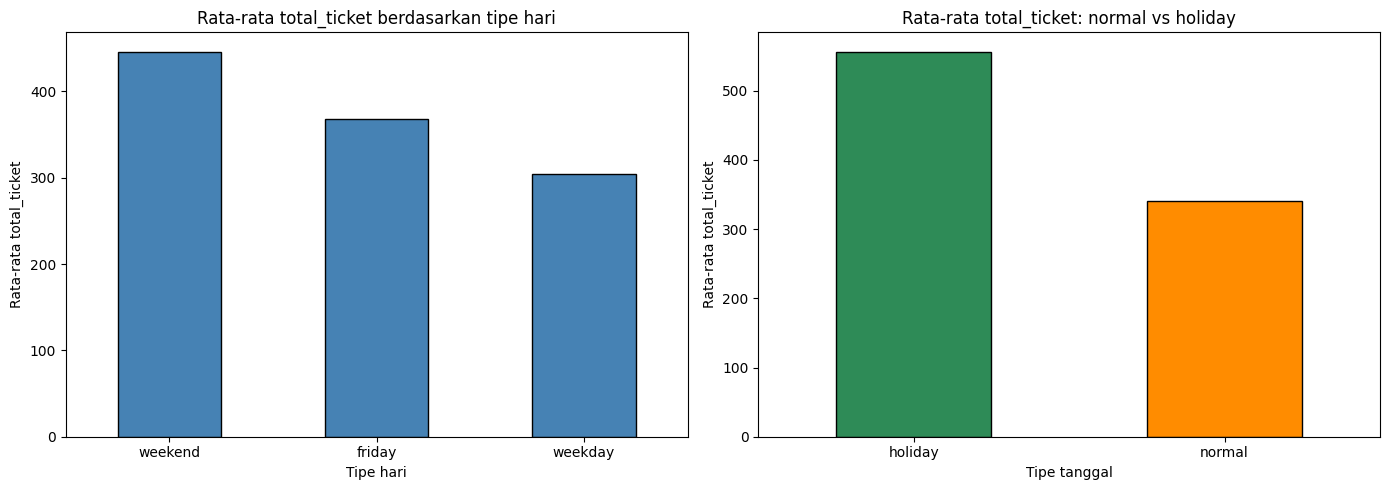

Jumlah hari libur terdeteksi: 18


,date,holiday_name
0,2025-04-01,Idulfitri 1446 H
17,2025-04-18,Wafat Yesus Kristus
19,2025-04-20,Kebangkitan Yesus Kristus (Paskah)
30,2025-05-01,Hari Buruh Internasional
41,2025-05-12,Hari Raya Waisak 2569 BE
58,2025-05-29,Kenaikan Yesus Kristus
61,2025-06-01,Hari Lahir Pancasila
66,2025-06-06,Idul Adha 1446 H
87,2025-06-27,1 Muharam Tahun Baru Islam 1447 H
138,2025-08-17,Proklamasi Kemerdekaan Republik Indonesia


Efek H-1, hari-H, dan H+1 untuk setiap hari libur:


,holiday_date,holiday_name,offset,date_show,mean_total_ticket
0,2025-04-01,Idulfitri 1446 H,-1,2025-03-31,NaN
1,2025-04-01,Idulfitri 1446 H,0,2025-04-01,574.753731
2,2025-04-01,Idulfitri 1446 H,1,2025-04-02,701.327091
3,2025-04-18,Wafat Yesus Kristus,-1,2025-04-17,603.520104
4,2025-04-18,Wafat Yesus Kristus,0,2025-04-18,889.448276
5,2025-04-18,Wafat Yesus Kristus,1,2025-04-19,804.912827
6,2025-04-20,Kebangkitan Yesus Kristus (Paskah),-1,2025-04-19,804.912827
7,2025-04-20,Kebangkitan Yesus Kristus (Paskah),0,2025-04-20,700.045802
8,2025-04-20,Kebangkitan Yesus Kristus (Paskah),1,2025-04-21,430.196005
9,2025-05-01,Hari Buruh Internasional,-1,2025-04-30,472.145205


Rata-rata efek berdasarkan offset (gabungan semua hari libur):


,count,mean,median
offset,,,
-1,10,447.900740,460.590135
0,11,554.027424,574.753731
1,11,466.240460,430.196005


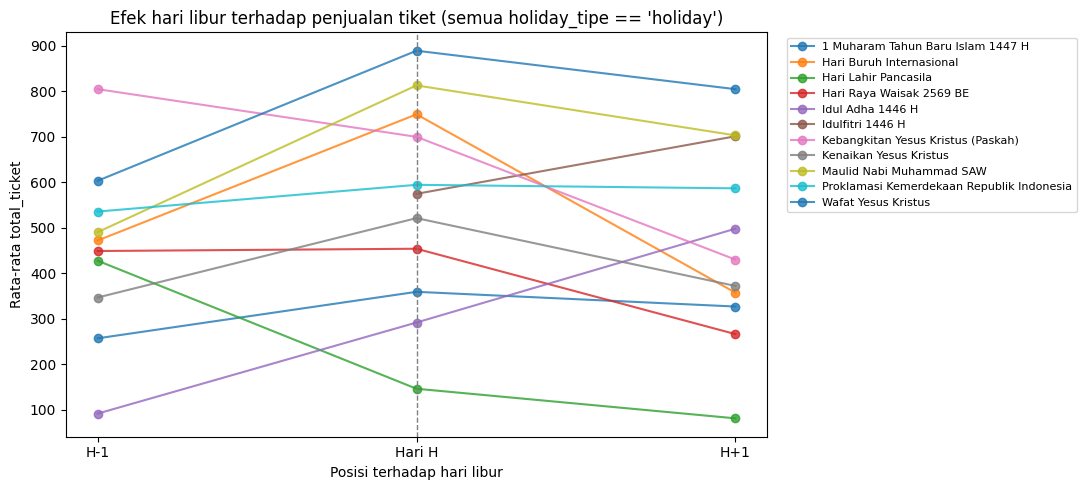

In [6]:
# Dampak hari libur dan efek H-1/H+1
import matplotlib.pyplot as plt

train_holiday = train.merge(
    holidays[["date", "day_tipe", "holiday_tipe", "holiday_name"]],
    left_on="date_show",
    right_on="date",
    how="left",
)

print("Rata-rata total_ticket berdasarkan tipe hari:")
day_summary = (
    train_holiday.groupby("day_tipe", dropna=False)["total_ticket"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(day_summary)

print("Rata-rata total_ticket berdasarkan normal vs holiday:")
holiday_summary = (
    train_holiday.groupby("holiday_tipe", dropna=False)["total_ticket"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(holiday_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
day_summary["mean"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Rata-rata total_ticket berdasarkan tipe hari")
axes[0].set_xlabel("Tipe hari")
axes[0].set_ylabel("Rata-rata total_ticket")
axes[0].tick_params(axis="x", rotation=0)

holiday_summary["mean"].plot(kind="bar", ax=axes[1], color=["seagreen", "darkorange"], edgecolor="black")
axes[1].set_title("Rata-rata total_ticket: normal vs holiday")
axes[1].set_xlabel("Tipe tanggal")
axes[1].set_ylabel("Rata-rata total_ticket")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

major_holidays = (
    holidays.loc[holidays["holiday_tipe"] == "holiday", ["date", "holiday_name"]]
    .drop_duplicates()
    .sort_values("date")
)
print(f"Jumlah hari libur terdeteksi: {len(major_holidays)}")
display(major_holidays)

daily_ticket = train.groupby("date_show", as_index=False)["total_ticket"].mean()

holiday_effect_rows = []
for _, event in major_holidays.iterrows():
    for offset in [-1, 0, 1]:
        event_date = event["date"] + pd.Timedelta(days=offset)
        matching = daily_ticket.loc[daily_ticket["date_show"] == event_date, "total_ticket"]
        holiday_effect_rows.append({
            "holiday_date": event["date"],
            "holiday_name": event["holiday_name"],
            "offset": offset,
            "date_show": event_date,
            "mean_total_ticket": matching.iloc[0] if len(matching) else np.nan,
        })

holiday_effect = pd.DataFrame(holiday_effect_rows)
print("Efek H-1, hari-H, dan H+1 untuk setiap hari libur:")
display(holiday_effect)
print("Rata-rata efek berdasarkan offset (gabungan semua hari libur):")
offset_summary = holiday_effect.groupby("offset")["mean_total_ticket"].agg(["count", "mean", "median"])
display(offset_summary)

# Catatan: banyak tanggal libur (holidays.csv sampai Apr 2026) berada di luar
# rentang train.csv (Apr-Sep 2025), jadi mean_total_ticket-nya otomatis NaN.
# Baris NaN itu wajar dan diabaikan saat plotting di bawah.
plt.figure(figsize=(11, 5))
for holiday_name, event_data in holiday_effect.groupby("holiday_name"):
    event_data = event_data.sort_values("offset")
    if event_data["mean_total_ticket"].isna().all():
        continue
    plt.plot(
        event_data["offset"],
        event_data["mean_total_ticket"],
        marker="o",
        linewidth=1.5,
        alpha=0.8,
        label=holiday_name,
    )
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.xticks([-1, 0, 1], ["H-1", "Hari H", "H+1"])
plt.xlabel("Posisi terhadap hari libur")
plt.ylabel("Rata-rata total_ticket")
plt.title("Efek hari libur terhadap penjualan tiket (semua holiday_tipe == \'holiday\')")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=1)
plt.tight_layout()
plt.show()


Distribusi skala klaster berdasarkan histori:


,count,mean,std,min,25%,50%,75%,max
mean_total_ticket,117.0,283.609691,183.045367,32.253061,174.354515,249.129239,342.679821,1422.579413
median_total_ticket,117.0,156.495726,65.572528,26.000000,117.000000,150.000000,192.000000,475.000000
mean_occupation_rate,117.0,29.177938,6.775113,14.435788,24.719357,28.357617,32.797396,63.789735
mean_total_show,117.0,6.178970,3.988652,2.877551,3.934227,4.790909,6.886792,30.206226
observations,117.0,1187.683761,549.198423,212.000000,821.000000,1123.000000,1477.000000,2899.000000


Klaster terbesar dan terkecil:


,mean_total_ticket,median_total_ticket,mean_occupation_rate,mean_total_show,observations
cinema_ids,,,,,
8dbfb7aeb4ed822b358347332ba630af,1422.579413,475.0,26.658348,30.206226,2827
4ed104ac0de10ba7eef50158603e0b32,901.404967,289.0,25.654115,23.276647,2899
108f9a4d181f12fd1b7e3c9adae38478,710.366332,276.0,21.988556,17.371566,2293
c4a19cbeb409639c836e4304976db0aa,696.665146,294.0,26.897217,14.106752,2192
0191582d75f94a412c0fa12d36bcee3f,615.950680,267.0,29.751705,10.678447,2575
5b8eaa351fae8e6d1e759e814d74c1c5,553.021086,246.0,28.592699,12.592514,1897
a9e141baa8b4ec825325397b16eeaae3,530.955273,201.0,24.044815,11.414136,1811
b704e8b10f13e14494b5a7a0ba39d9d9,530.001089,227.5,26.220508,14.994194,2756
015555fbcd8faef6b55a854605df0a87,527.256483,222.0,23.388100,12.291995,1774


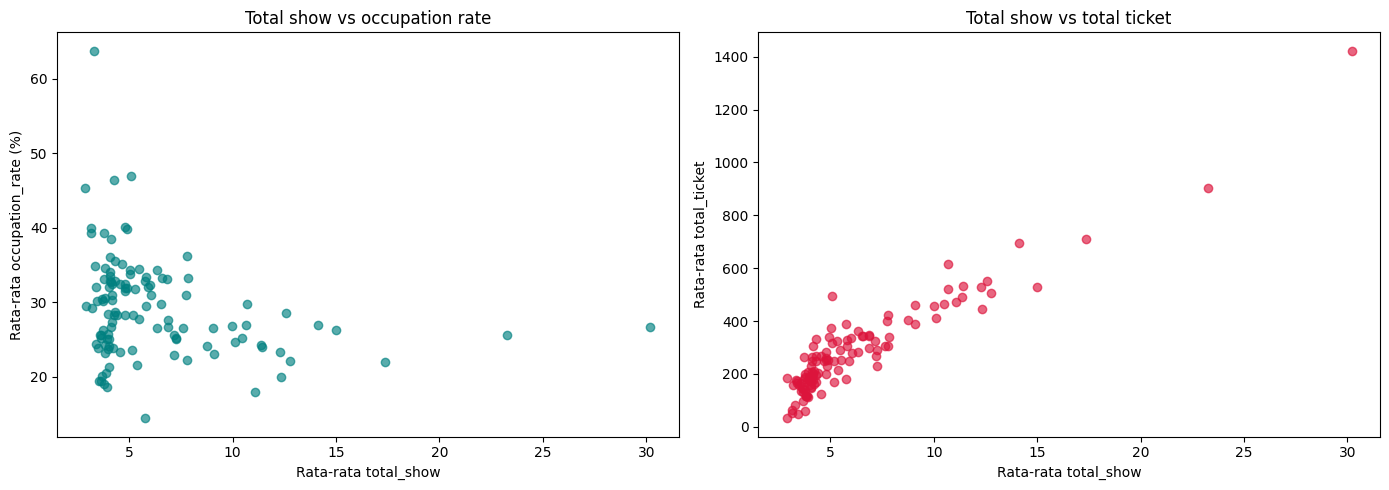

Estimasi kapasitas kursi per show per klaster:


,count,median,mean,min,max
count,117.000000,117.000000,117.000000,117.000000,117.000000
mean,1185.658120,147.792980,159.735394,88.235347,3062.495597
std,548.487657,34.032222,37.657587,47.474322,3096.475350
min,212.000000,24.247492,24.778618,21.346470,52.380952
25%,821.000000,134.594088,146.413493,38.834951,1142.857143
50%,1121.000000,148.222767,161.634757,103.174603,2000.000000
75%,1473.000000,164.587699,182.711732,126.026460,3523.809524
max,2897.000000,214.965986,227.336479,205.513784,15576.923077


,count,median,mean,min,max
cinema_ids,,,,,
26d1d720bc7e60c1b1a56630e3ba2c5d,651,214.965986,216.968888,151.098901,1396.103896
b2539b1f80254243391774489b1328aa,569,214.811477,227.336479,205.513784,6548.387097
c35e24eefa840ac2009279f1efc52288,820,214.457365,206.766815,126.984127,1142.857143
4ba87a86e02dd8a810032db35bf13c51,829,201.201201,164.418523,66.666667,1285.714286
45f553cca86b28fedd6115abdd0ae734,683,201.159626,212.304850,188.261351,5190.476190
afbb3b11f728a54ad1eb3ca34f602779,871,199.611462,223.182754,174.757282,5904.761905
3c41b96b56b0aab1ed5fc5e703499730,1268,193.423169,193.040468,23.296447,3000.000000
592095e0ddc2c230cf3002d72e9bac41,856,190.392184,193.063926,158.730159,1523.809524
716ede53fbca27fbe1c1a55d6667c2b5,1431,189.995190,220.814724,114.285714,1153.846154


In [7]:
# Perbandingan karakter antar cinema cluster
cluster_summary = (
    train.groupby("cinema_ids")
    .agg(
        mean_total_ticket=("total_ticket", "mean"),
        median_total_ticket=("total_ticket", "median"),
        mean_occupation_rate=("occupation_rate", "mean"),
        mean_total_show=("total_show", "mean"),
        observations=("total_ticket", "size"),
    )
    .sort_values("mean_total_ticket", ascending=False)
)
print("Distribusi skala klaster berdasarkan histori:")
display(cluster_summary.describe().T)
print("Klaster terbesar dan terkecil:")
display(pd.concat([cluster_summary.head(10), cluster_summary.tail(10)]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(
    cluster_summary["mean_total_show"],
    cluster_summary["mean_occupation_rate"],
    alpha=0.65,
    color="teal",
)
axes[0].set_title("Total show vs occupation rate")
axes[0].set_xlabel("Rata-rata total_show")
axes[0].set_ylabel("Rata-rata occupation_rate (%)")
axes[1].scatter(
    cluster_summary["mean_total_show"],
    cluster_summary["mean_total_ticket"],
    alpha=0.65,
    color="crimson",
)
axes[1].set_title("Total show vs total ticket")
axes[1].set_xlabel("Rata-rata total_show")
axes[1].set_ylabel("Rata-rata total_ticket")
plt.tight_layout()
plt.show()

# Reverse-engineer estimasi kapasitas kursi per show.
train["estimated_capacity_per_show"] = np.where(
    (train["total_show"] > 0) & (train["occupation_rate"] > 0),
    train["total_ticket"] / (train["total_show"] * train["occupation_rate"] / 100),
    np.nan,
)
capacity_by_cluster = (
    train.groupby("cinema_ids")["estimated_capacity_per_show"]
    .agg(["count", "median", "mean", "min", "max"])
    .sort_values("median", ascending=False)
)
print("Estimasi kapasitas kursi per show per klaster:")
display(capacity_by_cluster.describe())
display(capacity_by_cluster.head(10))

Baris tanpa harga kota-hari yang cocok: 277918
Jumlah baris asli (train): 138959 | setelah join & filter: 138959
Ringkasan harga tiket vs permintaan per kota:


,mean_price,mean_total_ticket,median_total_ticket,mean_occupation_rate,observations
city_name,,,,,
PALU,60753.935377,248.382767,151.0,35.212088,1207
BANJARMASIN,58653.061224,299.522449,190.0,39.892105,1715
GORONTALO,54312.333629,169.333629,116.0,28.337853,1127
MAKASSAR,53600.048864,364.851698,210.0,33.486540,4093
PONTIANAK,52991.228070,493.217544,329.5,46.977588,1140
...,...,...,...,...,...
PEKANBARU,33556.505223,265.881925,144.0,30.106682,3159
MAMUJU,33379.120879,165.142857,117.0,24.370316,728
BONDOWOSO,24395.448080,158.886202,117.0,23.846387,703


Korelasi harga rata-rata dengan permintaan kota:


,mean_price,mean_total_ticket,median_total_ticket,mean_occupation_rate,observations
mean_price,1.000000,0.281502,0.382500,0.469101,0.178072
mean_total_ticket,0.281502,1.000000,0.880131,0.134672,0.844175
median_total_ticket,0.382500,0.880131,1.000000,0.457712,0.617350
mean_occupation_rate,0.469101,0.134672,0.457712,1.000000,-0.060007
observations,0.178072,0.844175,0.617350,-0.060007,1.000000


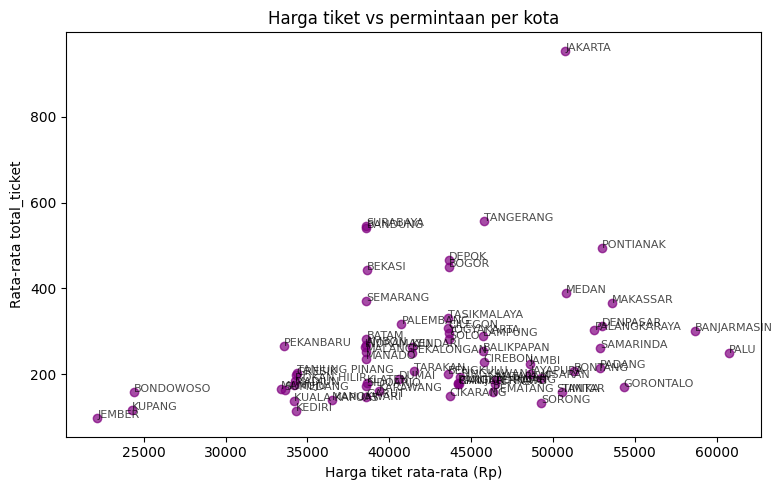

In [8]:
# Join harga tiket berdasarkan kota dan tipe hari
# 1. Join train dengan holidays untuk dapat day_tipe
train_h = train.merge(
    holidays.rename(columns={"date": "date_show"}),
    on="date_show",
    how="left",
)

# 2. Baru join dengan ticket_prices. Ini many-to-many by city_name karena tiap
#    kota punya 3 baris harga (Weekday/Friday/Weekend), makanya difilter oleh
#    price_day_normalized di bawah sebelum groupby, supaya tidak ada duplikasi baris.
train_prices = train_h.merge(
    ticket_prices,
    on="city_name",
    how="left",
    suffixes=("", "_price"),
)

train_prices["price_day_normalized"] = train_prices["day_tipe"].map({
    "weekday": "Weekday",
    "friday": "Friday",
    "weekend": "Weekend",
})

train_prices["city_day_price"] = np.where(
    train_prices["price_day"] == train_prices["price_day_normalized"],
    train_prices["ceil"],
    np.nan,
)

print("Baris tanpa harga kota-hari yang cocok:", train_prices["city_day_price"].isna().sum())

# Hapus baris duplikat hasil merge many-to-many, sisakan 1 baris harga per observasi asli
train_prices_clean = train_prices.dropna(subset=["city_day_price"])
print("Jumlah baris asli (train):", len(train), "| setelah join & filter:", len(train_prices_clean))

city_price_demand = (
    train_prices_clean.groupby("city_name")
    .agg(
        mean_price=("city_day_price", "mean"),
        mean_total_ticket=("total_ticket", "mean"),
        median_total_ticket=("total_ticket", "median"),
        mean_occupation_rate=("occupation_rate", "mean"),
        observations=("total_ticket", "size"),
    )
    .dropna()
)

print("Ringkasan harga tiket vs permintaan per kota:")
display(city_price_demand.sort_values("mean_price", ascending=False))

print("Korelasi harga rata-rata dengan permintaan kota:")
display(city_price_demand.corr(numeric_only=True))

plt.figure(figsize=(8, 5))
plt.scatter(
    city_price_demand["mean_price"],
    city_price_demand["mean_total_ticket"],
    alpha=0.7,
    color="purple",
)
for city, row in city_price_demand.iterrows():
    plt.annotate(city, (row["mean_price"], row["mean_total_ticket"]), fontsize=8, alpha=0.7)
plt.xlabel("Harga tiket rata-rata (Rp)")
plt.ylabel("Rata-rata total_ticket")
plt.title("Harga tiket vs permintaan per kota")
plt.tight_layout()
plt.show()


In [9]:
# Analisis genre, decay historis, dan normalisasi title format
movie_lookup = movies[["original_title", "genre"]].drop_duplicates("original_title")
train_movies = train.merge(
    movie_lookup,
    left_on="movie_title",
    right_on="original_title",
    how="left",
)
train_movies["date_rank"] = train_movies.groupby(
    ["movie_title", "cinema_ids"]
)["date_show"].rank(method="dense", ascending=True)

# Bandingkan D1 dengan hari-hari berikutnya untuk pasangan yang punya histori cukup.
pair_first_last = (
    train_movies[train_movies["date_rank"] <= 7]
    .groupby(["movie_title", "cinema_ids", "genre", "date_rank"], dropna=False)["total_ticket"]
    .mean()
    .reset_index()
)
pair_decay = pair_first_last.pivot_table(
    index=["movie_title", "cinema_ids", "genre"],
    columns="date_rank",
    values="total_ticket",
)
pair_decay["decay_d7_vs_d1"] = pair_decay.get(7, np.nan) / pair_decay.get(1, np.nan)
print("Decay median berdasarkan genre (nilai < 1 berarti turun):")
display(
    pair_decay.reset_index()
    .groupby("genre", dropna=False)["decay_d7_vs_d1"]
    .agg(["count", "median", "mean"])
    .sort_values("median", ascending=False)
    .head(30)
)

format_pattern = r"2D|3D|IMAX|DUBBING"
test["has_format_marker"] = test["movie_title"].str.contains(
    format_pattern, case=False, regex=True, na=False
)
format_titles = test.loc[test["has_format_marker"], "movie_title"].drop_duplicates().sort_values()
print(f"Jumlah title test dengan penanda format: {len(format_titles)}")
display(format_titles.to_frame("movie_title").head(50))
print("Jumlah title katalog yang menjadi duplikat setelah normalisasi format:")
movie_normalized = normalize_title(movies["original_title"])
normalized_duplicates = movies.assign(normalized_title=movie_normalized).groupby(
    "normalized_title"
)["original_title"].nunique()
display(normalized_duplicates[normalized_duplicates > 1].sort_values(ascending=False).head(30).to_frame("jumlah_title"))

Decay median berdasarkan genre (nilai < 1 berarti turun):


,count,median,mean
genre,,,
"Action, Adventure",82,3.908626,8.860421
Romance,1,3.857143,3.857143
"Animation, Fantasy, Drama",115,3.046316,3.104064
"Horror, Thriller",132,2.322275,3.490578
"Horror, Thriller, Mystery",107,1.467611,1.903770
Drama,922,1.407515,2.079236
Action,273,1.238095,1.530248
"Drama, Thriller",108,1.139189,1.462701
"Crime, Action",113,1.034483,1.209618


Jumlah title test dengan penanda format: 20


,movie_title
6237,AVATAR: FIRE AND ASH (3D)
6370,AVATAR: FIRE AND ASH (IMAX 3D)
8582,BLADES OF THE GUARDIANS (IMAX 2D)
11466,DANUR: THE LAST CHAPTER (IMAX 2D)
13979,EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)
19047,HOPPERS (3D)
19110,HOPPERS (IMAX 2D)
28140,MERCY (IMAX 2D)
39697,PREDATOR: BADLANDS (3D)
39711,PREDATOR: BADLANDS (IMAX 2D)


Jumlah title katalog yang menjadi duplikat setelah normalisasi format:


,jumlah_title
normalized_title,


In [10]:
# Pemeriksaan representasi ekstrem dan inkonsistensi numerik
# FIX: cell ini sebelumnya menghitung ulang D1-D3 dengan logika terpisah dari cell
# scale/MASE di atas (duplikasi). Sekarang pakai ulang compute_history_stats()
# yang sudah didefinisikan sebelumnya, supaya D1-D3 hanya dihitung dengan satu
# definisi yang konsisten di seluruh notebook.
pair_d1_d3 = compute_history_stats(test_history, n_days=3).rename(
    columns={"mean_ticket": "mean_d1_d3", "max_ticket": "max_d1_d3"}
)

print("Pasangan dengan D1-D3 tertinggi:")
display(pair_d1_d3.sort_values("mean_d1_d3", ascending=False).head(20))
print("Pasangan dengan D1-D3 terendah:")
display(pair_d1_d3.sort_values("mean_d1_d3", ascending=True).head(20))

zero_show_positive_ticket = train[(train["total_show"] == 0) & (train["total_ticket"] > 0)]
positive_show_zero_ticket = train[(train["total_show"] > 0) & (train["total_ticket"] == 0)]
print("\nAnomali total_show=0 tetapi total_ticket>0:", len(zero_show_positive_ticket))
print("Anomali total_show>0 tetapi total_ticket=0:", len(positive_show_zero_ticket))

invalid_occupation = train[
    (train["occupation_rate"] < 0) | (train["occupation_rate"] > 100)
]
print("occupation_rate di luar rentang 0-100:", len(invalid_occupation))
print("Ringkasan nilai ekstrem total_ticket:")
display(train["total_ticket"].describe(percentiles=[.01, .05, .5, .95, .99]).to_frame())


Pasangan dengan D1-D3 tertinggi:


,movie_title,cinema_ids,mean_d1_d3,max_d1_d3,min_ticket,mean_total_show,mean_occupation_rate,n_obs
275,AGAK LAEN: MENYALA PANTIKU!,8dbfb7aeb4ed822b358347332ba630af,24117.333333,37989,13860,208.666667,58.516667,3
249,AGAK LAEN: MENYALA PANTIKU!,4ed104ac0de10ba7eef50158603e0b32,18399.000000,27676,12460,169.666667,58.433333,3
960,AVATAR: FIRE AND ASH,8dbfb7aeb4ed822b358347332ba630af,15887.000000,19068,14296,179.666667,52.250000,3
219,AGAK LAEN: MENYALA PANTIKU!,108f9a4d181f12fd1b7e3c9adae38478,10179.666667,17411,5219,88.666667,55.403333,3
934,AVATAR: FIRE AND ASH,4ed104ac0de10ba7eef50158603e0b32,9652.333333,10610,8885,141.333333,45.270000,3
297,AGAK LAEN: MENYALA PANTIKU!,b704e8b10f13e14494b5a7a0ba39d9d9,9102.333333,13393,5686,102.000000,52.973333,3
296,AGAK LAEN: MENYALA PANTIKU!,b4972b48997defae8304bc9c41220c7c,8046.000000,14175,4083,63.666667,55.203333,3
674,ALAS ROBAN,8dbfb7aeb4ed822b358347332ba630af,7332.666667,7856,6876,93.000000,37.876667,3
213,AGAK LAEN: MENYALA PANTIKU!,0191582d75f94a412c0fa12d36bcee3f,6947.000000,9922,4915,61.666667,53.733333,3
897,AVATAR: FIRE AND ASH,0191582d75f94a412c0fa12d36bcee3f,6494.333333,7270,5652,54.000000,65.473333,3


Pasangan dengan D1-D3 terendah:


,movie_title,cinema_ids,mean_d1_d3,max_d1_d3,min_ticket,mean_total_show,mean_occupation_rate,n_obs
4414,MARIA,66d433e397ff7f3d460500704fd40a5a,1.0,1,1,2.0,1.05,1
1288,BLACK PHONE 2,4a61d7e09bbe3868d79af81be96ed6ee,1.0,1,1,2.5,0.87,2
8722,STRAY KIDS: THE DOMINATE EXPERIENCE,981569adf232c53afe751c8c660db8d9,1.0,1,1,1.0,0.00,1
8571,SOSOK KETIGA: LINTRIK,c71a18e33d4b7c73c8124c65fc3e6f1c,1.0,1,1,3.0,0.00,1
11140,"WE, EVERYDAY",4fc3fc370b299876663c7d5c90595853,1.0,1,1,2.0,0.00,1
6934,REGRETTING YOU,4a61d7e09bbe3868d79af81be96ed6ee,1.0,1,1,2.0,1.03,1
9187,THE BRIDE!,ef2896a95abe2a2b4cfee245dc1e36ec,1.0,1,1,4.0,0.00,1
3668,JUARA SEJATI,b4972b48997defae8304bc9c41220c7c,1.0,1,1,5.0,0.00,1
7457,SADALI,f7734bb329cacfe21ce854ae822b6115,1.0,1,1,5.0,0.00,1
3659,JUARA SEJATI,8750b9ee0b0c6c6afcfcb2a05e60efc0,1.0,1,1,5.0,0.00,1



Anomali total_show=0 tetapi total_ticket>0: 0
Anomali total_show>0 tetapi total_ticket=0: 0
occupation_rate di luar rentang 0-100: 0
Ringkasan nilai ekstrem total_ticket:


,total_ticket
count,138959.000000
mean,354.122072
std,725.927987
min,1.000000
1%,5.000000
5%,18.000000
50%,161.000000
95%,1264.000000
99%,3136.420000
max,32845.000000


## 4. Feature engineering, modeling, dan evaluation

Kode pipeline lengkap ada di sel berikutnya: pengambilan metadata TMDB opsional, penggabungan katalog, fitur D1-D3 dan kalender, tabel fitur, holdout temporal, baseline MASE, serta LightGBM L1. Default Run All memakai metadata lokal yang sudah diunduh dan tidak memanggil API. Fungsi `compute_history_stats()` dari notebook ini dipakai langsung.

Skor MASE merupakan validasi lokal pada `train.csv`, bukan skor submission/Kaggle.

In [11]:
"""Feature, temporal validation, baseline and L1 boosting pipeline.

Usage: python scripts/build_pipeline.py [--fetch-metadata]
Fetching requires TMDB_READ_ACCESS_TOKEN (or TMDB_API_KEY).
"""
from __future__ import annotations
import argparse, ast, json, os, re, sys, time
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "dataset").is_dir():
    raise FileNotFoundError("Run this notebook with the project folder as the working directory")
DATA = ROOT / "dataset"
OUT = ROOT / "data"
EXT = ROOT / "external_data"
SEED = 2026

def load(name):
    return pd.read_csv(DATA / f"{name}.csv")

def fetch_metadata():
    import requests
    def safe_get(url, **kwargs):
        try:
            response=requests.get(url,**kwargs)
            response.raise_for_status()
            return response
        except requests.RequestException as exc:
            status=getattr(getattr(exc,"response",None),"status_code",None)
            # Never print a requests exception: its URL may contain the API key.
            raise RuntimeError(f"TMDB HTTP request failed (status={status or 'unavailable'}); credential value omitted") from None
    token = os.getenv("TMDB_API_RAT")
    key = os.getenv("TMDB_API_KEY")
    envfile=ROOT/".env"
    if (not token or not key) and envfile.exists():
        for line in envfile.read_text(encoding="utf-8").splitlines():
            if "=" not in line or line.lstrip().startswith("#"): continue
            name,value=line.split("=",1)
            name=name.strip().upper(); value=value.strip().strip("\"'")
            if name=="TMDB_API_RAT" and not token: token=value
            if name=="TMDB_API_KEY" and not key: key=value
    if not token and not key:
        raise RuntimeError("Set TMDB_API_RAT or TMDB_API_KEY in environment or project .env")
    test = load("test")
    catalog = load("movies")
    missing = sorted(set(test.movie_title.dropna()) - set(catalog.original_title.dropna()))
    rows=[]; audit=[]
    for title in missing:
        headers={"Authorization":f"Bearer {token}"} if token else {}
        query=re.sub(r"\b(2D|3D|IMAX|DUBBING)\b", "", title, flags=re.I).strip()
        params={"query":query,"language":"en-US"}
        if key: params["api_key"]=key
        resp=safe_get("https://api.themoviedb.org/3/search/movie",params=params,headers=headers,timeout=30)
        results=resp.json().get("results",[])
        norm=lambda x: re.sub(r"[^a-z0-9]", "", re.sub(r"\b(2D|3D|IMAX|DUBBING)\b", "", str(x),flags=re.I).lower())
        exact=[x for x in results if norm(x.get("title"))==norm(title)]
        if not exact:
            audit.append((title,"not_found_or_title_mismatch")); continue
        best=max(exact,key=lambda x:x.get("popularity",0)); mid=best["id"]
        detail_params={"append_to_response":"credits,release_dates","language":"en-US"}
        if key: detail_params["api_key"]=key
        detail=safe_get(f"https://api.themoviedb.org/3/movie/{mid}",params=detail_params,headers=headers,timeout=30)
        m=detail.json()
        credits=m.get("credits",{}); crew=credits.get("crew",[]); cast=credits.get("cast",[])
        directors=[x["name"] for x in crew if x.get("job")=="Director"]
        producers=[x["name"] for x in crew if x.get("job")=="Producer"]
        writers=[x["name"] for x in crew if x.get("department")=="Writing"]
        certs=[]
        for country in m.get("release_dates",{}).get("results",[]):
            if country.get("iso_3166_1")=="ID": certs += [x.get("certification") for x in country.get("release_dates",[]) if x.get("certification")]
        rows.append({"original_title":title,"age_rating":certs[0] if certs else np.nan,
          "genre":"|".join(x["name"] for x in m.get("genres",[])),"producer":"|".join(producers),
          "director":"|".join(directors),"writer":"|".join(writers),"casts":"|".join(x["name"] for x in cast[:10]),
          "overview":m.get("overview"),"popularity":m.get("popularity"),"runtime":m.get("runtime"),
          "original_language":m.get("original_language"),"release_year":str(m.get("release_date",""))[:4],
          "released":m.get("release_date"),"imdb_id":m.get("imdb_id"),"imdb_rating":np.nan,"tmdb_id":mid})
        audit.append((title,"matched:"+str(mid))); time.sleep(.25)
    EXT.mkdir(exist_ok=True)
    pd.DataFrame(rows).to_csv(EXT/"missing_movies_metadata.csv",index=False)
    (EXT/"README.md").write_text("""# External movie metadata\n\nSource: TMDB API v3. Endpoints: `/3/search/movie` and `/3/movie/{movie_id}?append_to_response=credits,release_dates`. Retrieval date: 2026-09-29. API authentication and attribution/terms: https://developer.themoviedb.org/docs/authentication-application and https://www.themoviedb.org/api-terms-of-use. Rows are accepted only on normalized title match after removing 2D/3D/IMAX/DUBBING format markers.\n\n`age_rating` uses Indonesian (`ID`) release certification when available and remains blank when TMDB has no certification. Results and unmatched titles are recorded in `acquisition_audit.csv`. Titles attempted are test titles absent from `movies.csv`; see the audit for completed titles.\n\nSet `TMDB_API_RAT` (API Read Access Token) or `TMDB_API_KEY` in the environment or project `.env` before running `python scripts/build_pipeline.py --fetch-metadata`. Credentials are read locally and never written to project outputs.\n""",encoding="utf-8")
    pd.DataFrame(audit,columns=["test_title","result"]).to_csv(EXT/"acquisition_audit.csv",index=False)

def history_stats(hist, n_days=3):
    # Load the exact reusable implementation from main.ipynb, avoiding a second
    # definition that could drift from the competition's D1-D3 logic.
    nb=json.loads((ROOT/"main.ipynb").read_text(encoding="utf-8"))
    fn=None
    for cell in nb["cells"]:
        if cell["cell_type"]!="code": continue
        try: tree=ast.parse("".join(cell.get("source",[])))
        except SyntaxError: continue
        fn=next((n for n in tree.body if isinstance(n,ast.FunctionDef) and n.name=="compute_history_stats"),None)
        if fn is not None: break
    if fn is None: raise RuntimeError("compute_history_stats() not found in main.ipynb")
    mod=ast.fix_missing_locations(ast.Module(body=[fn],type_ignores=[]))
    scope={"pd":pd,"np":np}; exec(compile(mod,"main.ipynb","exec"),scope)
    return scope["compute_history_stats"](hist,n_days=n_days)

def mase(y, pred, scale):
    return float(np.mean(np.abs(np.asarray(y)-np.asarray(pred))/np.maximum(1,np.asarray(scale))))

def load_movie_metadata():
    catalog=load("movies")
    extfile=EXT/"missing_movies_metadata.csv"
    if not extfile.exists(): return catalog
    external=pd.read_csv(extfile)
    if external.empty: return catalog
    combined=catalog.merge(external,on="original_title",how="outer",suffixes=("_catalog","_external"))
    for col in ["age_rating","genre","producer","director","writer","casts"]:
        a=combined.get(f"{col}_catalog"); b=combined.get(f"{col}_external")
        if a is not None and b is not None: combined[col]=a.combine_first(b)
        elif a is not None: combined[col]=a
        elif b is not None: combined[col]=b
    return combined

def make_features():
    train=load("train"); hist=load("test_history"); test=load("test")
    movies=load_movie_metadata(); holidays=load("holidays"); prices=load("ticket_prices")
    for d,col in [(train,"date_show"),(hist,"date_show"),(test,"date_show"),(holidays,"date")]: d[col]=pd.to_datetime(d[col])
    # Historical cluster profile and capacity, computed from train only.
    tr=train.copy()
    tr["capacity_est"] = np.where((tr.total_show>0)&(tr.occupation_rate>0),tr.total_ticket/(tr.total_show*tr.occupation_rate/100),np.nan)
    clusters=tr.groupby("cinema_ids",as_index=False).agg(cluster_mean_ticket=("total_ticket","mean"),cluster_mean_occupation=("occupation_rate","mean"),cluster_mean_show=("total_show","mean"),capacity_per_show=("capacity_est","median"))
    hstats=history_stats(hist).rename(columns={"mean_ticket":"scale_raw"})
    feat=test.merge(hstats,on=["movie_title","cinema_ids"],how="left").merge(clusters,on="cinema_ids",how="left")
    feat["scale"]=feat.scale_raw.clip(lower=1)
    feat=feat.merge(movies[["original_title","genre","age_rating"]].drop_duplicates("original_title"),left_on="movie_title",right_on="original_title",how="left")
    # Create calendar features and nearest holiday distance; holiday dates not listed are normal days.
    cal=holidays.rename(columns={"date":"date_show"})[["date_show","day_tipe","holiday_tipe","holiday_name"]]
    feat=feat.merge(cal,on="date_show",how="left")
    feat["day_tipe"]=feat.day_tipe.fillna(feat.date_show.dt.dayofweek.map(lambda d:"weekend" if d>=5 else "weekday"))
    feat["holiday_tipe"]=feat.holiday_tipe.fillna("normal")
    hol_dates=holidays.loc[holidays.holiday_tipe.eq("holiday"),"date"].dropna().sort_values().values.astype("datetime64[ns]")
    dates=feat.date_show.values.astype("datetime64[ns]")
    if len(hol_dates):
        delta=(dates[:,None]-hol_dates[None,:]).astype("timedelta64[D]").astype(int)
        nearest=np.abs(delta).argmin(axis=1)
        feat["days_to_holiday"]=delta[np.arange(len(delta)),nearest] # negative = before (H-), positive = after (H+)
    else: feat["days_to_holiday"]=999
    feat["days_since_d1"]=feat.groupby(["movie_title","cinema_ids"]).date_show.transform("rank")+3
    # Attach price by city and calendar bucket.
    daymap={"weekday":"Weekday","friday":"Friday","weekend":"Weekend"}
    feat["price_day"]=feat.day_tipe.map(daymap)
    feat=feat.merge(prices,on=["city_name","price_day"],how="left")
    return feat

def run_pipeline(fetch_external=False):
    if fetch_external: fetch_metadata()
    OUT.mkdir(exist_ok=True)
    f=make_features()
    # parquet if engine installed; retain CSV fallback for portability.
    try: f.to_parquet(OUT/"feature_table.parquet",index=False)
    except ImportError: f.to_csv(OUT/"feature_table.csv",index=False)
    print(f"Feature rows: {len(f):,}; test titles missing genre/rating: {f.loc[f.genre.isna(),'movie_title'].nunique():,}/{f.loc[f.age_rating.isna(),'movie_title'].nunique():,}")
    history_floor=history_stats(load("test_history"))
    history_floor=history_floor[history_floor.mean_ticket.eq(1)][["movie_title","cinema_ids"]]
    target_pairs=f[["movie_title","cinema_ids"]].drop_duplicates()
    target_floor=history_floor.merge(target_pairs,on=["movie_title","cinema_ids"])
    print(f"History pairs at scale=1: {len(history_floor)}; overlapping forecast test pairs: {len(target_floor)} (test labels unavailable)")
    # Rolling temporal forecast: each validation pair uses its final 7 train
    # observations as D4-D10 and the immediately preceding three as D1-D3.
    tr=load("train"); tr["date_show"]=pd.to_datetime(tr.date_show)
    metadata=load_movie_metadata()[["original_title","genre","age_rating"]].drop_duplicates("original_title")
    tr=tr.merge(metadata,left_on="movie_title",right_on="original_title",how="left")
    tr=tr.sort_values(["movie_title","cinema_ids","date_show"])
    grp=tr.groupby(["movie_title","cinema_ids"],sort=False)
    tr["row_in_pair"]=grp.cumcount()
    pair_sizes=tr.groupby(["movie_title","cinema_ids"]).row_in_pair.transform("max")+1
    tr["val_start"]=pair_sizes-7
    valid=tr[(tr.row_in_pair>=tr.val_start)&(tr.val_start>=3)].copy()
    history=tr[tr.row_in_pair<tr.val_start].copy()
    history["tail_rank"]=history.groupby(["movie_title","cinema_ids"]).row_in_pair.transform(lambda x:x.max()-x)
    prior=history[history.tail_rank<3]
    stats=history_stats(prior).rename(columns={"mean_ticket":"scale_raw"})
    valid=valid.merge(stats[["movie_title","cinema_ids","scale_raw"]],on=["movie_title","cinema_ids"],how="left")
    valid["scale"]=valid.scale_raw.clip(lower=1)
    valid["target_norm"]=valid.total_ticket/valid.scale
    valid["day_tipe"]=valid.date_show.dt.dayofweek.map(lambda d:"weekend" if d>=5 else ("friday" if d==4 else "weekday"))
    daymap={"weekday":"Weekday","friday":"Friday","weekend":"Weekend"}
    multip={"weekday":1.0,"friday":1.2,"weekend":1.46}
    dayrank=valid.row_in_pair-valid.val_start+1
    decay=np.power(.9,np.maximum(0,dayrank-1))
    baseline=valid.scale.to_numpy()*valid.day_tipe.map(multip).to_numpy()*decay
    print("Temporal holdout rows:",len(valid),"baseline MASE:",mase(valid.total_ticket,baseline,valid.scale))
    low=valid[valid.scale.eq(1)]
    print("scale=1 rows:",len(low),"MASE:",mase(low.total_ticket,low.total_ticket.mean() if len(low) else [],low.scale) if len(low) else "n/a")
    # Train on earlier observations only. Per-pair preceding three tickets define
    # each sample's scale; validation rows stay outside model fitting.
    try:
        # Avoid joblib probing Windows physical cores through deprecated WMIC.
        os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))
        from lightgbm import LGBMRegressor
        prices=load("ticket_prices")
        holidays=load("holidays"); holidays["date"]=pd.to_datetime(holidays.date)
        cats=["cinema_ids","city_name","genre","age_rating","day_tipe","holiday_tipe","price_day"]
        # Attach train-only cluster features to the historic training examples.
        train_rows=tr[tr.row_in_pair<tr.val_start].copy()
        # Recompute cluster aggregates from the training window only, excluding
        # each pair's held-out D4-D10 observations to prevent feature leakage.
        train_rows["capacity_est"]=np.where((train_rows.total_show>0)&(train_rows.occupation_rate>0),train_rows.total_ticket/(train_rows.total_show*train_rows.occupation_rate/100),np.nan)
        temporal_clusters=train_rows.groupby("cinema_ids",as_index=False).agg(cluster_mean_ticket=("total_ticket","mean"),cluster_mean_occupation=("occupation_rate","mean"),cluster_mean_show=("total_show","mean"),capacity_per_show=("capacity_est","median"))
        train_rows["past_mean"]=train_rows.groupby(["movie_title","cinema_ids"]).total_ticket.transform(lambda s:s.shift().rolling(3,min_periods=3).mean())
        train_rows=train_rows.dropna(subset=["past_mean"])
        train_rows=train_rows.merge(temporal_clusters,on="cinema_ids",how="left")
        train_rows["target_norm"]=train_rows.total_ticket/train_rows.past_mean.clip(lower=1)
        train_rows["scale"]=train_rows.past_mean.clip(lower=1)
        train_rows["day_tipe"]=train_rows.date_show.dt.dayofweek.map(lambda d:"weekend" if d>=5 else ("friday" if d==4 else "weekday"))
        train_rows=train_rows.merge(holidays.rename(columns={"date":"date_show"})[["date_show","holiday_tipe"]],on="date_show",how="left")
        train_rows["holiday_tipe"]=train_rows.holiday_tipe.fillna("normal")
        train_rows["price_day"]=train_rows.day_tipe.map(daymap)
        train_rows=train_rows.merge(prices,on=["city_name","price_day"],how="left")
        valid=valid.merge(temporal_clusters,on="cinema_ids",how="left")
        # Holiday and price features for the held-out dates.
        valid=valid.merge(holidays.rename(columns={"date":"date_show"})[["date_show","holiday_tipe"]],on="date_show",how="left",suffixes=("","_cal"))
        valid["holiday_tipe"]=valid["holiday_tipe"].fillna("normal")
        valid["price_day"]=valid.day_tipe.map(daymap)
        valid=valid.merge(prices,on=["city_name","price_day"],how="left",suffixes=("","_price"))
        modelcols=cats+["scale","cluster_mean_ticket","cluster_mean_occupation","cluster_mean_show","capacity_per_show"]
        modelcols=[c for c in modelcols if c in valid]
        X=valid[modelcols].copy(); X_train=train_rows[modelcols].copy()
        for c in cats:
            if c in X:
                levels=pd.Index(pd.concat([X[c],X_train[c]]).fillna("Unknown").astype(str).unique())
                X[c]=pd.Categorical(X[c].fillna("Unknown").astype(str),categories=levels)
                X_train[c]=pd.Categorical(X_train[c].fillna("Unknown").astype(str),categories=levels)
        model=LGBMRegressor(objective="mae",random_state=SEED,n_estimators=400,verbosity=-1)
        model.fit(X_train,train_rows.target_norm,categorical_feature=[c for c in cats if c in X])
        pred=np.maximum(0,model.predict(X))*valid.scale
        print("Temporal validation MASE:",mase(valid.total_ticket,pred,valid.scale))
    except ImportError: print("LightGBM unavailable; rerun the pinned dependency-install cell at the top")

run_pipeline(fetch_external=False)


Feature rows: 72,611; test titles missing genre/rating: 0/0
History pairs at scale=1: 23; overlapping forecast test pairs: 1 (test labels unavailable)


Temporal holdout rows: 35728 baseline MASE: 0.4283175058039589
scale=1 rows: 0 MASE: n/a


C:\Users\pevan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\pevan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\pevan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\pevan\AppData\Local\Programs\Python\Pytho

Temporal validation MASE: 0.45282839483090176
